# Processamento Digital de Imagens — Atividade 1

**Capacitação:** Visão Computacional — Residência em TIC43
**Unidade 1 | Capítulo 1 | Tarefa 2**
**Prof.:** Alyson Bezerra / Matheus Araújo
**Aluno:** Ednardo Pinheiro Peixoto

Tema escolhido:
- Classe A: Copo
- Classe B: Garrafa


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os


## Upload das imagens

Enviar:
- 5 imagens da classe Copo
- 5 imagens da classe Garrafa


In [6]:
uploaded = files.upload()


Saving copo1.jpg to copo1 (2).jpg
Saving copo2.jpg to copo2 (2).jpg
Saving copo3.jpg to copo3 (2).jpg
Saving copo4.jpg to copo4 (2).jpg
Saving copo5.jpg to copo5 (2).jpg
Saving garrafa1.jpg to garrafa1 (2).jpg
Saving garrafa2.jpg to garrafa2 (2).jpg
Saving garrafa3.jpg to garrafa3 (2).jpg
Saving garrafa4.jpg to garrafa4 (2).jpg
Saving garrafa5.jpg to garrafa5 (2).jpg


## Organização das imagens

Nome sugerido:

Copo:
- copo1.jpg
- copo2.jpg
- copo3.jpg
- copo4.jpg
- copo5.jpg

Garrafa:
- garrafa1.jpg
- garrafa2.jpg
- garrafa3.jpg
- garrafa4.jpg
- garrafa5.jpg

*(Se o nome do arquivo enviado for diferente, renomeie com `os.rename('nome_enviado.jpg', 'copo1.jpg')` antes de seguir.)*


# Registro das imagens

## Dispositivo utilizado
Smartphone modelo: Motorola Edge 30 Neo — sem embelezamento/filtros automáticos

## Condições de iluminação
- Luz natural
- Luz artificial
- Ambiente com sombra

## Distâncias aproximadas
- Entre 30 cm e 1 metro, variando ângulo por classe

## Observações
Algumas fotos iniciais foram descartadas por apresentarem desfoque ou por repetirem 
excessivamente o mesmo ângulo/distância dentro da mesma classe. O conjunto final foi 
selecionado para garantir variação real de iluminação, ângulo e distância entre as 
5 imagens de cada classe.

## Visualização geral do mini dataset


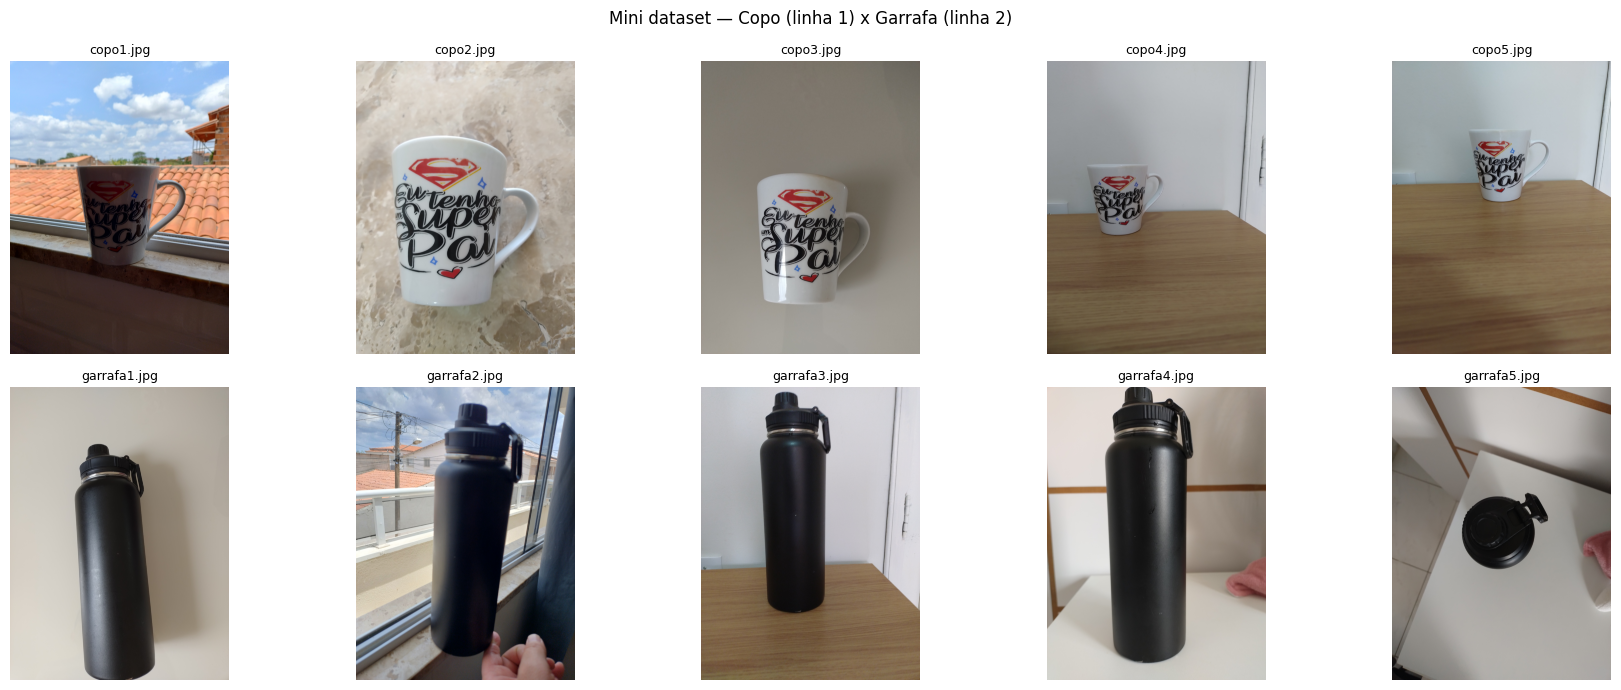

In [7]:
copos = [f"copo{i}.jpg" for i in range(1, 6)]
garrafas = [f"garrafa{i}.jpg" for i in range(1, 6)]

fig, ax = plt.subplots(2, 5, figsize=(18, 7))

for j, nome in enumerate(copos):
    img = cv2.cvtColor(cv2.imread(nome), cv2.COLOR_BGR2RGB)
    ax[0, j].imshow(img)
    ax[0, j].set_title(nome, fontsize=9)
    ax[0, j].axis('off')

for j, nome in enumerate(garrafas):
    img = cv2.cvtColor(cv2.imread(nome), cv2.COLOR_BGR2RGB)
    ax[1, j].imshow(img)
    ax[1, j].set_title(nome, fontsize=9)
    ax[1, j].axis('off')

plt.suptitle("Mini dataset — Copo (linha 1) x Garrafa (linha 2)")
plt.tight_layout()
plt.show()


# Parte A — Análise de Resolução

**Problema:** verificar o impacto visual e técnico de reduzir a resolução espacial de uma imagem.

Geramos, para 1 exemplo de cada classe: resolução original, 50% e 20%.


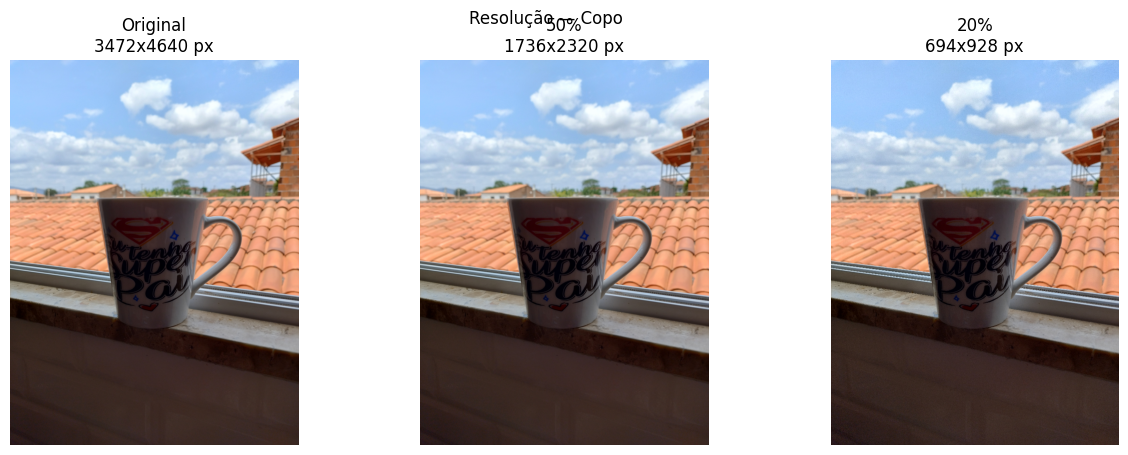

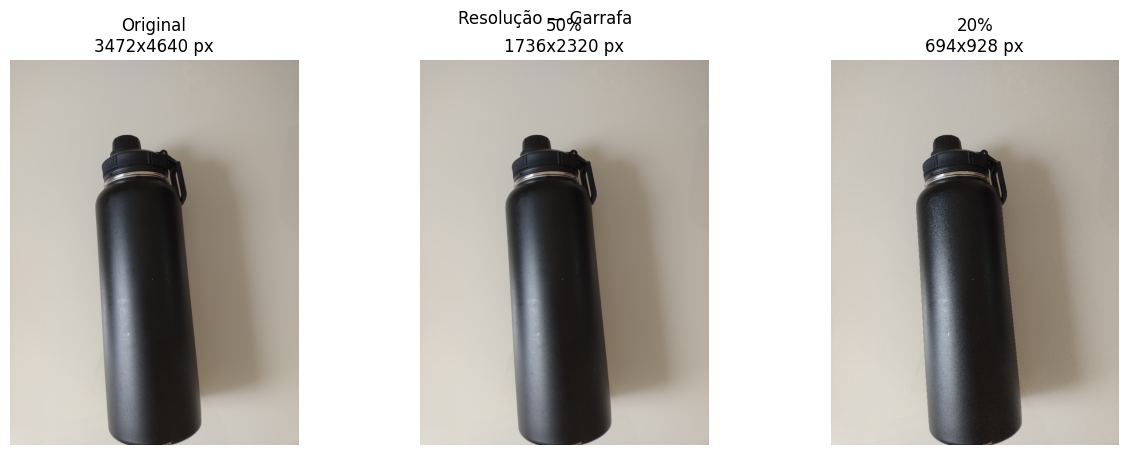

In [8]:
def analisar_resolucao(caminho, titulo_classe):
    img = cv2.imread(caminho)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    altura, largura = img.shape[:2]
    img_50 = cv2.resize(img, (largura // 2, altura // 2))
    img_20 = cv2.resize(img, (int(largura * 0.2), int(altura * 0.2)))

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for a, im, t in zip(ax, [img, img_50, img_20],
                        ["Original", "50%", "20%"]):
        a.imshow(im)
        a.set_title(f"{t}\n{im.shape[1]}x{im.shape[0]} px")
        a.axis('off')
    plt.suptitle(f"Resolução — {titulo_classe}")
    plt.show()

    return img, img_50, img_20

copo_orig, copo_50, copo_20 = analisar_resolucao("copo1.jpg", "Copo")
garrafa_orig, garrafa_50, garrafa_20 = analisar_resolucao("garrafa1.jpg", "Garrafa")


## Comentário

**Copo:** Na resolução original (3472x4640px) o texto "Eu tenho um Super Pai"
e o logo da Superman ficam nítidos e legíveis. Em 50% (1736x2320px) ainda
dá pra ler o texto sem esforço. Em 20% (694x928px) as letras menores do
texto começam a perder definição nas bordas, ficando um pouco serrilhadas,
embora o contorno geral da caneca ainda seja reconhecível.

**Garrafa:** Como o objeto é mais uniforme (sem textura ou texto), a perda de
qualidade é menos perceptível visualmente entre as três resoluções — o
contorno e a silhueta da garrafa permanecem claros mesmo em 20%. Isso
mostra que objetos com detalhes finos (texto, padrões) são mais sensíveis
à redução de resolução do que objetos com superfícies lisas.

Ao reduzir a resolução da imagem, ocorre perda de detalhes importantes.
Na versão com 50% da resolução ainda é possível identificar claramente
o objeto. Na versão com 20%, detalhes finos desaparecem, podendo
prejudicar tarefas de visão computacional como reconhecimento de texto
ou classificação de objetos com padrões complexos.


# Parte B — Espaço de Cor

**Problema:** comparar como a mesma imagem é representada em RGB, HSV e escala de cinza.

Conversões:
- RGB
- HSV
- Escala de cinza


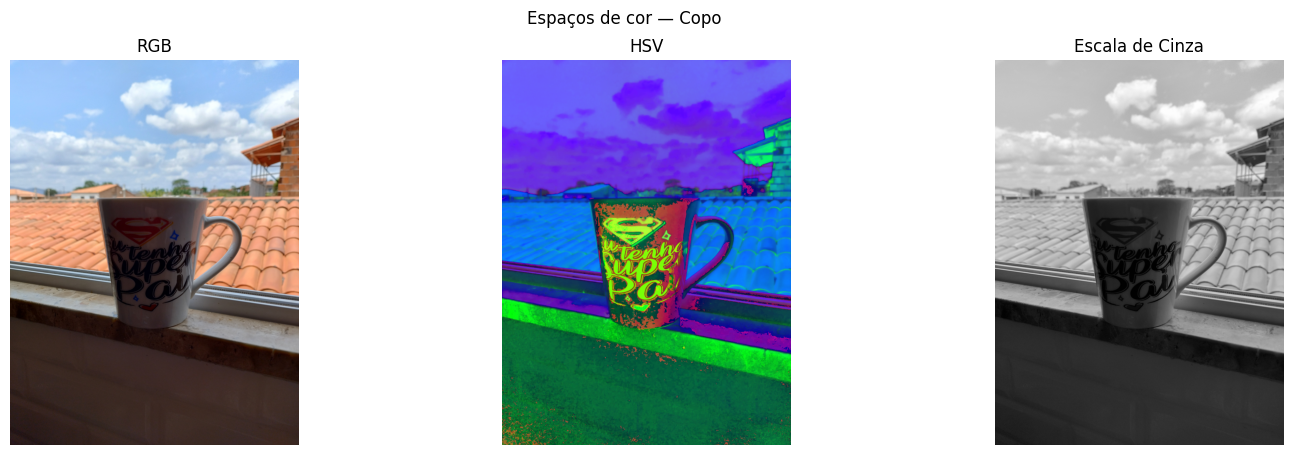

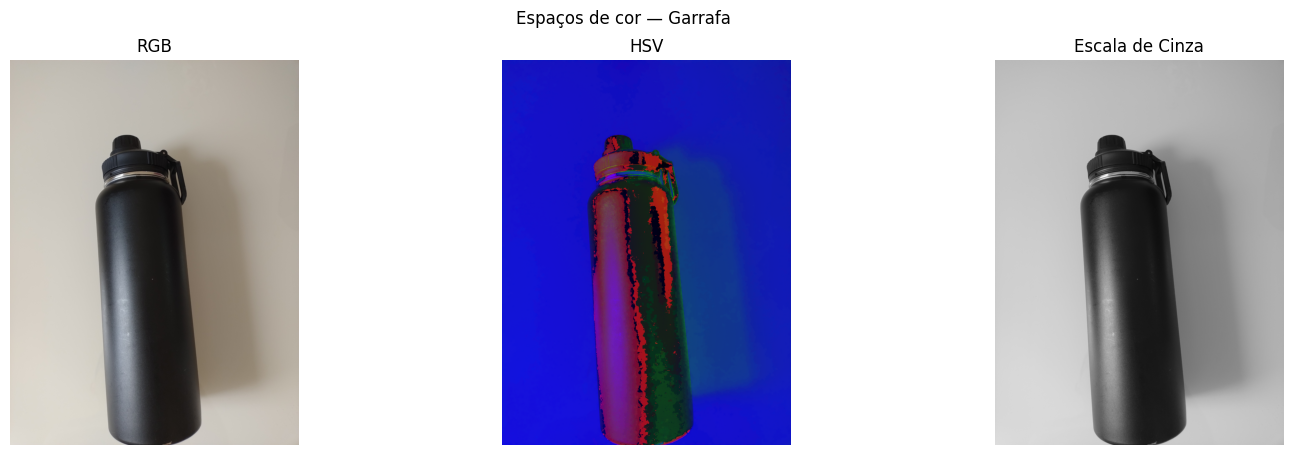

In [9]:
def analisar_espaco_cor(caminho, titulo_classe):
    img_bgr = cv2.imread(caminho)

    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].imshow(rgb); ax[0].set_title("RGB")
    ax[1].imshow(hsv); ax[1].set_title("HSV")
    ax[2].imshow(gray, cmap='gray'); ax[2].set_title("Escala de Cinza")
    for a in ax:
        a.axis('off')
    plt.suptitle(f"Espaços de cor — {titulo_classe}")
    plt.show()

analisar_espaco_cor("copo1.jpg", "Copo")
analisar_espaco_cor("garrafa1.jpg", "Garrafa")


## B.1 — Observando os canais R, G e B separadamente

**Problema:** um pixel colorido não é um único número — ele carrega três valores (R, G, B). Vamos visualizar cada canal isoladamente como se fosse uma imagem em tons de cinza, para ver que região da cena cada canal realça mais.


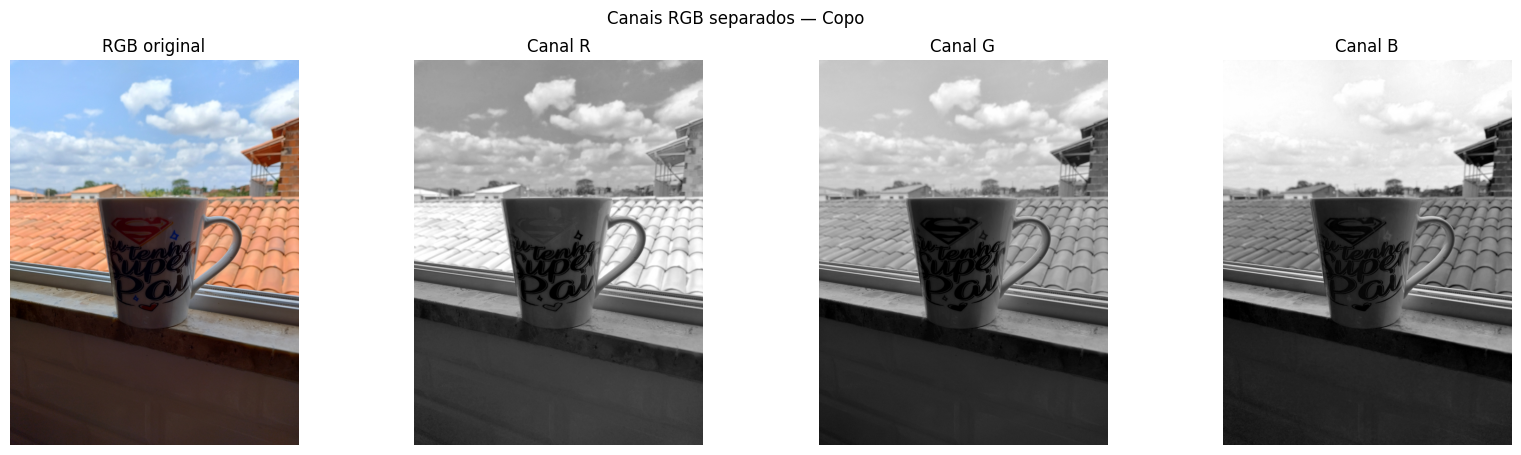

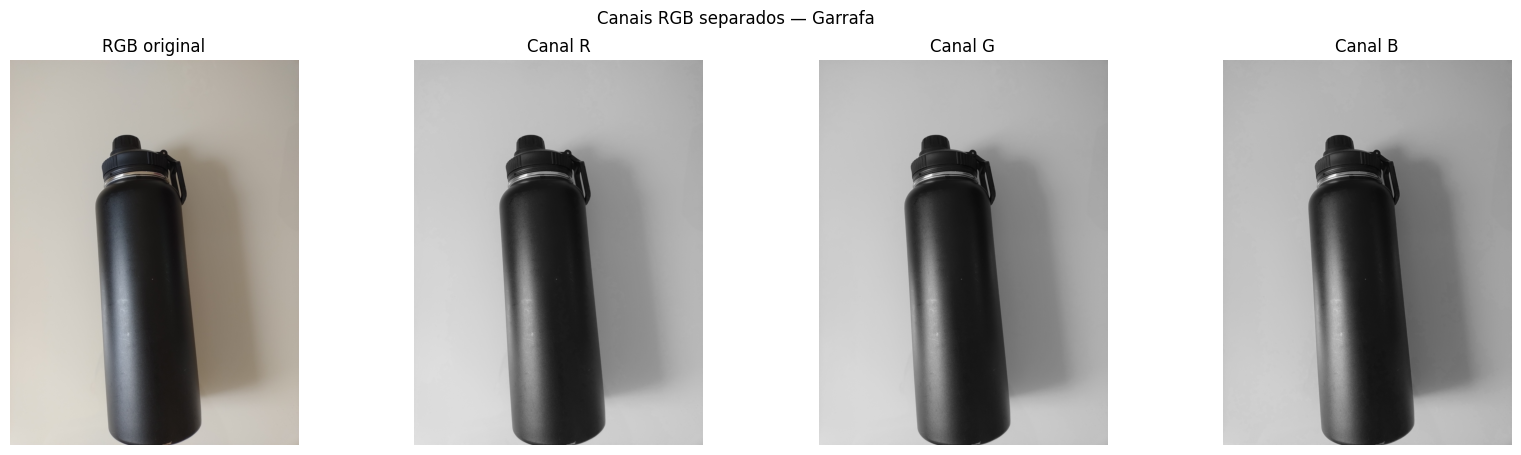

In [10]:
def separar_canais_rgb(caminho, titulo_classe):
    img_bgr = cv2.imread(caminho)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    canal_r = img_rgb[:, :, 0]
    canal_g = img_rgb[:, :, 1]
    canal_b = img_rgb[:, :, 2]

    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    ax[0].imshow(img_rgb); ax[0].set_title("RGB original")
    ax[1].imshow(canal_r, cmap='gray', vmin=0, vmax=255); ax[1].set_title("Canal R")
    ax[2].imshow(canal_g, cmap='gray', vmin=0, vmax=255); ax[2].set_title("Canal G")
    ax[3].imshow(canal_b, cmap='gray', vmin=0, vmax=255); ax[3].set_title("Canal B")
    for a in ax:
        a.axis('off')
    plt.suptitle(f"Canais RGB separados — {titulo_classe}")
    plt.show()

separar_canais_rgb("copo1.jpg", "Copo")
separar_canais_rgb("garrafa1.jpg", "Garrafa")


### Checkpoint (conforme aula 2 prática)

- Os três canais possuem as mesmas dimensões espaciais? Sim — cada canal (R, G, B) tem a mesma largura e altura da imagem original, pois é apenas uma "fatia" de cor, não uma redução de tamanho.
- As regiões claras são iguais nos três canais? Não. No Copo, a região do céu aparece bem clara no canal B (azul) e mais escura no canal R. No corpo escuro do copo, os três canais ficam parecidos e escuros, pois é uma cor neutra/preta. Na Garrafa (cor cinza/preta uniforme), os três canais ficam bem parecidos entre si, já que não há muita variação de cor saturada no objeto.
- O que uma região clara em um canal indica sobre aquela componente de cor? Indica  alta intensidade daquela cor primária naquele ponto — por exemplo, uma região clara no canal B indica presença forte de azul ali (como no céu de fundo da foto do copo).


## Diferenças visuais observadas

O copo, por estar em uma cena com céu, telhado e outros elementos coloridos, mostra diferenças bem visíveis entre os canais — o céu se destaca no canal B, o telhado alaranjado se destaca mais no canal R. Já a garrafa, sendo um objeto de cor neutra sobre fundo neutro, apresenta os três canais quase idênticos visualmente, com pouca variação de intensidade entre eles.

RGB:
- Mantém as cores naturais da imagem.

HSV:
- Destaca informações de tonalidade e brilho.
- Facilita segmentação baseada em cor.
- A exibição direta do array HSV com paleta RGB parece "artificial"/pseudocolorida, pois os canais representam Matiz/Saturação/Valor, não Vermelho/Verde/Azul.

Escala de cinza:
- Remove informações de cor.
- Mantém intensidade luminosa.

## Aplicações

RGB:
- Classificação de objetos
- Visualização convencional

HSV:
- Detecção de cores
- Rastreamento de objetos (ex.: localizar algo vermelho independente da sombra)

Escala de cinza:
- Detecção de bordas
- OCR
- Redução de custo computacional


# Parte C — Quantização

**Problema:** avaliar o efeito de reduzir os níveis de cinza disponíveis por pixel.

Níveis utilizados:
- 256 níveis
- 64 níveis
- 32 níveis
- 2 níveis


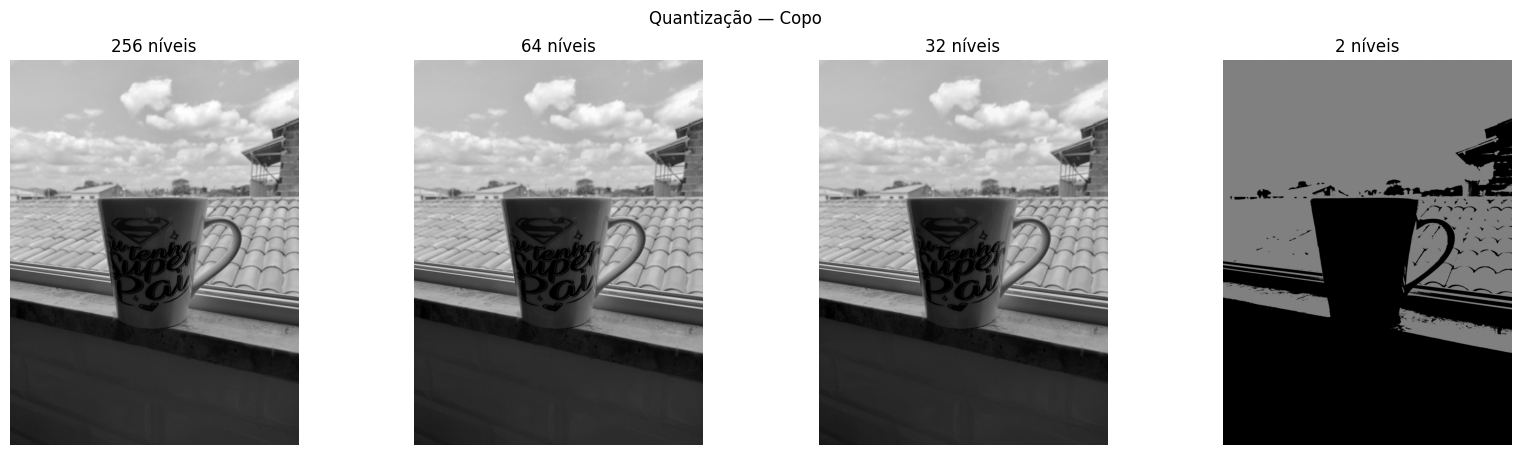

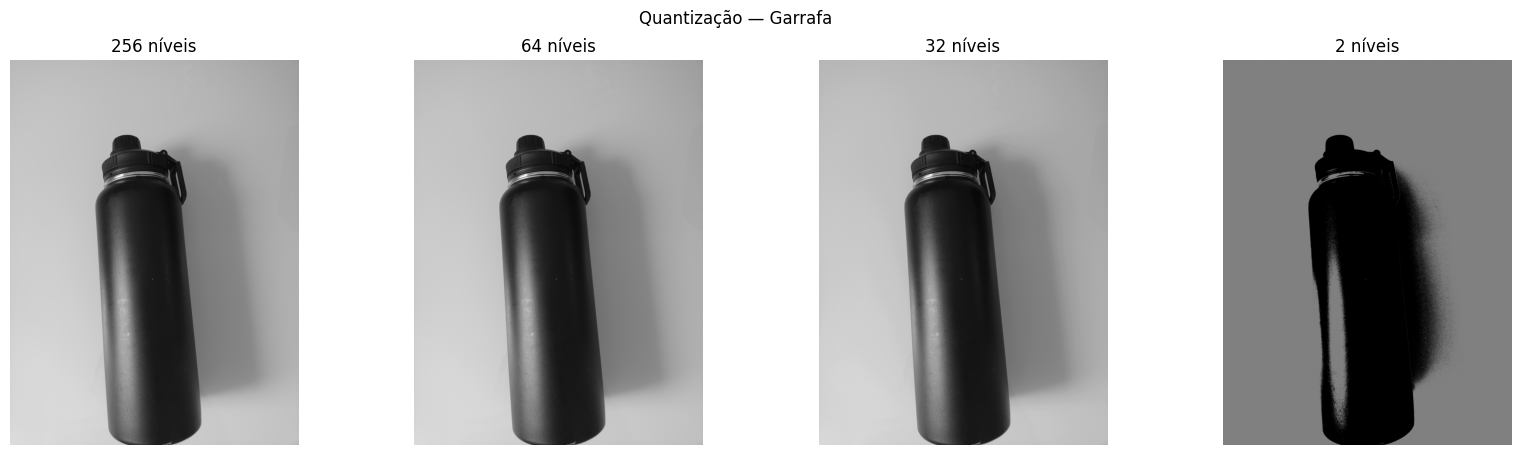

In [11]:
def quantizar(imagem, niveis):
    # Mesma lógica usada na aula 2 prática: agrupa os valores originais
    # em uma quantidade menor de níveis igualmente espaçados.
    passo = 256 / niveis
    resultado = np.floor(imagem.astype(np.float32) / passo) * passo
    return np.clip(resultado, 0, 255).astype(np.uint8)

def analisar_quantizacao(caminho, titulo_classe):
    img = cv2.imread(caminho, 0)  # já carrega em escala de cinza

    q64 = quantizar(img, 64)
    q32 = quantizar(img, 32)
    q2 = quantizar(img, 2)

    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    for a, im, t in zip(ax, [img, q64, q32, q2],
                        ["256 níveis", "64 níveis", "32 níveis", "2 níveis"]):
        a.imshow(im, cmap='gray', vmin=0, vmax=255)
        a.set_title(t)
        a.axis('off')
    plt.suptitle(f"Quantização — {titulo_classe}")
    plt.show()

analisar_quantizacao("copo1.jpg", "Copo")
analisar_quantizacao("garrafa1.jpg", "Garrafa")


## Observações

Com menos níveis de cinza:
- ocorre perda gradual de detalhes
- aparecem regiões mais "chapadas" (efeito posterizado)
- há aumento do contraste aparente em algumas áreas

A versão com 64 níveis ainda mantém boa qualidade visual e seria a mais equilibrada 
para o dataset.

A versão com 2 níveis perde muitos detalhes e seria mais útil em:
- segmentação binária (separar objeto do fundo)
- detecção de bordas/silhuetas simples
- OCR simples ou detecção de formas

Porém, para tarefas de classificação como a deste dataset (Copo x Garrafa), a perda 
de detalhes em 2 níveis prejudicaria a distinção de características importantes, 
como o texto do copo.

# Parte D — Formato de Arquivo

**Problema:** comparar tamanho e qualidade entre um formato com compressão (JPEG) e um sem perdas (PNG).

Formatos:
- JPEG com compressão
- PNG sem perdas


In [12]:
def analisar_formato(caminho, prefixo):
    img = cv2.imread(caminho)

    caminho_jpg = f"{prefixo}_compressao.jpg"
    caminho_png = f"{prefixo}_sem_perda.png"

    cv2.imwrite(caminho_jpg, img, [cv2.IMWRITE_JPEG_QUALITY, 30])
    cv2.imwrite(caminho_png, img)

    jpg_size = os.path.getsize(caminho_jpg) / 1024
    png_size = os.path.getsize(caminho_png) / 1024

    print(f"[{prefixo}] Tamanho JPEG: {jpg_size:.2f} KB | Tamanho PNG: {png_size:.2f} KB "
          f"(PNG é {png_size / jpg_size:.1f}x maior)")

analisar_formato("copo1.jpg", "copo")
analisar_formato("garrafa1.jpg", "garrafa")


[copo] Tamanho JPEG: 450.26 KB | Tamanho PNG: 20756.76 KB (PNG é 46.1x maior)
[garrafa] Tamanho JPEG: 388.95 KB | Tamanho PNG: 21399.36 KB (PNG é 55.0x maior)


## Observações

**Diferença visual percebida:** Com qualidade 30 o JPEG já mostra leves artefatos de compressão perto de bordas, enquanto o PNG mantém a imagem idêntica ao original

**Hipótese sobre impacto em tarefas de PDI:** o JPEG é mais leve e adequado para datasets grandes de classificação (onde pequenas perdas não atrapalham), enquanto o PNG é preferível quando é necessário preservar detalhes exatos — por exemplo, máscaras de segmentação ou imagens que serão usadas em análise de bordas/microdefeitos, onde artefatos de compressão poderiam ser confundidos com informação real.


# Parte E — Estrutura do mini dataset

**Problema:** entregar o dataset organizado em pastas, no padrão usado em projetos de Machine Learning.

Organização final:

```
dataset/
  classe_A_copo/
    copo1.jpg ... copo5.jpg
  classe_B_garrafa/
    garrafa1.jpg ... garrafa5.jpg
```


In [13]:
os.makedirs("dataset/classe_A_copo", exist_ok=True)
os.makedirs("dataset/classe_B_garrafa", exist_ok=True)

import shutil

for nome in copos:
    shutil.copy(nome, os.path.join("dataset/classe_A_copo", nome))

for nome in garrafas:
    shutil.copy(nome, os.path.join("dataset/classe_B_garrafa", nome))

print("Estrutura final:")
for root, dirs, arquivos in os.walk("dataset"):
    print(root)
    for f in arquivos:
        print("  ", f)


Estrutura final:
dataset
dataset/classe_A_copo
   copo2.jpg
   copo3.jpg
   copo1.jpg
   copo5.jpg
   copo4.jpg
dataset/classe_B_garrafa
   garrafa4.jpg
   garrafa5.jpg
   garrafa1.jpg
   garrafa3.jpg
   garrafa2.jpg


In [14]:
# Compacta o dataset final para entrega/download
shutil.make_archive("mini_dataset_copo_garrafa", "zip", ".", "dataset")

from google.colab import files as colab_files
colab_files.download("mini_dataset_copo_garrafa.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusão

**Interpretação geral:** Este estudo mostrou como diferentes técnicas de processamento de imagem impactam a qualidade e a informação disponível em um dataset de visão computacional. A redução de resolução e de níveis de quantização causa perda progressiva de detalhes finos (como texto e bordas), o que pode prejudicar tarefas de reconhecimento fino, embora a forma geral dos objetos permaneça identificável. A conversão para escala de cinza
elimina a informação de cor, útil quando o formato/textura importa mais que a cor, mas prejudicial em cenários onde a cor é o principal critério discriminante entre classes. Já a escolha de formato de arquivo (JPEG com compressão vs. PNG sem perdas) envolve um trade-off entre tamanho de arquivo e fidelidade — um classificador de imagens tolera bem JPEG em resolução moderada, enquanto aplicações que exigem precisão de borda (ex.: segmentação médica) se beneficiam mais de PNG.

